In [6]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [7]:
BASE = Path.home() / "Downloads" / "responsible ai"

# Dataset 1: FairFace
FAIRFACE_TRAIN = BASE / "FairFace Race" / "train"
FAIRFACE_VAL   = BASE / "FairFace Race" / "val"

# Dataset 2: UTKFace
UTK_DIR = BASE / "archive" / "UTKFace"

# Dataset 3: Adience
ADIENCE_FACES = BASE / "AdienceBenchmarkGenderAndAgeClassification" / "AdienceBenchmarkGenderAndAgeClassification" / "faces"
ADIENCE_FOLDS = BASE / "AdienceBenchmarkGenderAndAgeClassification"

print("FairFace train exists:", FAIRFACE_TRAIN.exists())
print("UTKFace exists:       ", UTK_DIR.exists())
print("Adience exists:       ", ADIENCE_FACES.exists())

FairFace train exists: True
UTKFace exists:        True
Adience exists:        True


In [8]:
rows = []

for race_folder in FAIRFACE_TRAIN.iterdir():
    for img in race_folder.glob("*.jpg"):
        rows.append({"filepath": str(img), "race": race_folder.name, "split": "train"})

for race_folder in FAIRFACE_VAL.iterdir():
    for img in race_folder.glob("*.jpg"):
        rows.append({"filepath": str(img), "race": race_folder.name, "split": "val"})

df_fairface = pd.DataFrame(rows)
df_fairface["source"] = "fairface"

print("FairFace shape:", df_fairface.shape)
df_fairface.head()

FairFace shape: (97698, 4)


,filepath,race,split,source
0,/Users/namratabhoyar/Downloads/responsible ai/...,Indian,train,fairface
1,/Users/namratabhoyar/Downloads/responsible ai/...,Indian,train,fairface
2,/Users/namratabhoyar/Downloads/responsible ai/...,Indian,train,fairface
3,/Users/namratabhoyar/Downloads/responsible ai/...,Indian,train,fairface
4,/Users/namratabhoyar/Downloads/responsible ai/...,Indian,train,fairface


In [12]:
RACE_MAP   = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Other"}
GENDER_MAP = {0: "Male",  1: "Female"}

rows = []
skipped = 0

for img in UTK_DIR.iterdir():

    # Only process proper .jpg files, skip .chip and anything else
    if not img.name.endswith(".jpg"):
        skipped += 1
        continue

    parts = img.stem.split("_")

    # Need at least 3 parts: age, gender, race
    if len(parts) < 3:
        skipped += 1
        continue

    # Wrap in try/except in case any value is still not a number
    try:
        rows.append({
            "filepath": str(img),
            "age":      int(parts[0]),
            "gender":   GENDER_MAP.get(int(parts[1]), "Unknown"),
            "race":     RACE_MAP.get(int(parts[2]),   "Unknown"),
            "source":   "utk"
        })
    except ValueError:
        skipped += 1
        continue

df_utk = pd.DataFrame(rows)

print("UTKFace loaded:", len(df_utk), "images")
print("Skipped files :", skipped)
df_utk.head()

UTKFace loaded: 23705 images
Skipped files : 3


,filepath,age,gender,race,source
0,/Users/namratabhoyar/Downloads/responsible ai/...,9,Female,Asian,utk
1,/Users/namratabhoyar/Downloads/responsible ai/...,36,Male,Black,utk
2,/Users/namratabhoyar/Downloads/responsible ai/...,86,Female,White,utk
3,/Users/namratabhoyar/Downloads/responsible ai/...,26,Female,White,utk
4,/Users/namratabhoyar/Downloads/responsible ai/...,1,Female,Asian,utk


In [13]:
fold_files = [ADIENCE_FOLDS / f"fold_{i}_data.txt" for i in range(5)]

dfs = []
for f in fold_files:
    dfs.append(pd.read_csv(f, sep="\t"))

df_adience = pd.concat(dfs, ignore_index=True)
df_adience.columns = df_adience.columns.str.strip()
df_adience["source"] = "adience"

print("Adience shape:", df_adience.shape)
df_adience.head()


Adience shape: (19370, 13)


,user_id,original_image,face_id,age,gender,x,y,dx,dy,tilt_ang,fiducial_yaw_angle,fiducial_score,source
0,30601258@N03,10399646885_67c7d20df9_o.jpg,1,"(25, 32)",f,0,414,1086,1383,-115,30,17,adience
1,30601258@N03,10424815813_e94629b1ec_o.jpg,2,"(25, 32)",m,301,105,640,641,0,0,94,adience
2,30601258@N03,10437979845_5985be4b26_o.jpg,1,"(25, 32)",f,2395,876,771,771,175,-30,74,adience
3,30601258@N03,10437979845_5985be4b26_o.jpg,3,"(25, 32)",m,752,1255,484,485,180,0,47,adience
4,30601258@N03,11816644924_075c3d8d59_o.jpg,2,"(25, 32)",m,175,80,769,768,-75,0,34,adience


In [14]:
# Standardize columns before combining
df_fairface_clean = df_fairface[["filepath", "race", "source"]].copy()
df_fairface_clean["age"]    = None
df_fairface_clean["gender"] = None

df_utk_clean = df_utk[["filepath", "age", "gender", "race", "source"]].copy()

df_adience_clean = df_adience[["source"]].copy()
df_adience_clean["filepath"] = None   # built separately if needed
df_adience_clean["age"]      = df_adience["age"]
df_adience_clean["gender"]   = df_adience["gender"]
df_adience_clean["race"]     = None   # Adience has no race column

# Stack all 3
df_all = pd.concat([df_fairface_clean, df_utk_clean, df_adience_clean], ignore_index=True)

print("=== COMBINED ===")
print(df_all.shape)
print(df_all["source"].value_counts())

=== COMBINED ===
(140773, 5)
source
fairface    97698
utk         23705
adience     19370
Name: count, dtype: int64


In [15]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140773 entries, 0 to 140772
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   filepath  121403 non-null  object
 1   race      121403 non-null  object
 2   source    140773 non-null  object
 3   age       42327 non-null   object
 4   gender    42296 non-null   object
dtypes: object(5)
memory usage: 5.4+ MB


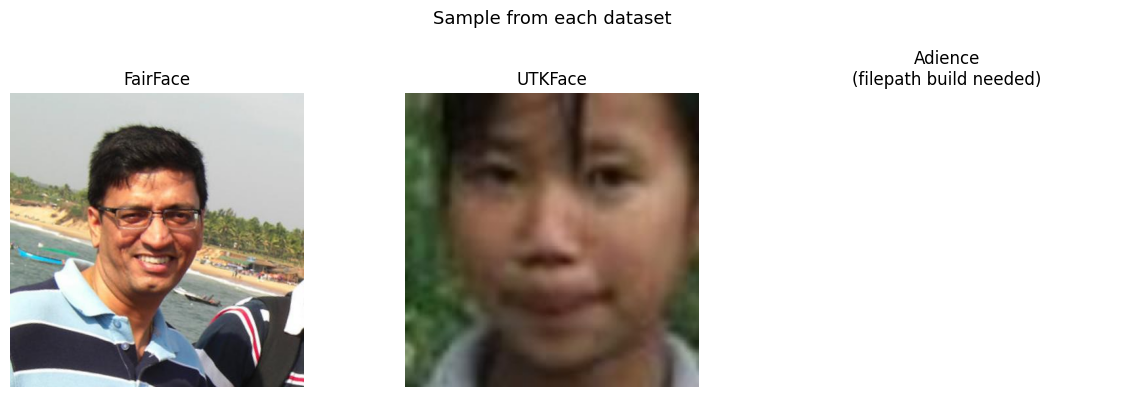

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# FairFace sample
img1 = mpimg.imread(df_fairface_clean["filepath"].dropna().iloc[0])
axes[0].imshow(img1)
axes[0].set_title("FairFace")
axes[0].axis("off")

# UTKFace sample
img2 = mpimg.imread(df_utk_clean["filepath"].dropna().iloc[0])
axes[1].imshow(img2)
axes[1].set_title("UTKFace")
axes[1].axis("off")

# Adience — no direct filepath built yet
axes[2].set_title("Adience\n(filepath build needed)")
axes[2].axis("off")

plt.suptitle("Sample from each dataset", fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
# Adience image path format:
# faces / <user_id> / coarse_tilt_aligned_face.<face_id>.<original_image>

def build_adience_path(row):
    filename = f"coarse_tilt_aligned_face.{row['face_id']}.{row['original_image']}"
    return str(ADIENCE_FACES / str(row['user_id']) / filename)

df_adience["filepath"] = df_adience.apply(build_adience_path, axis=1)

# Check how many files actually exist on disk
df_adience["file_exists"] = df_adience["filepath"].apply(os.path.exists)

print("Total Adience rows  :", len(df_adience))
print("Files found on disk :", df_adience["file_exists"].sum())
df_adience[["user_id", "age", "gender", "filepath", "file_exists"]].head()

Total Adience rows  : 19370
Files found on disk : 3086


,user_id,age,gender,filepath,file_exists
0,30601258@N03,"(25, 32)",f,/Users/namratabhoyar/Downloads/responsible ai/...,False
1,30601258@N03,"(25, 32)",m,/Users/namratabhoyar/Downloads/responsible ai/...,False
2,30601258@N03,"(25, 32)",f,/Users/namratabhoyar/Downloads/responsible ai/...,False
3,30601258@N03,"(25, 32)",m,/Users/namratabhoyar/Downloads/responsible ai/...,False
4,30601258@N03,"(25, 32)",m,/Users/namratabhoyar/Downloads/responsible ai/...,False


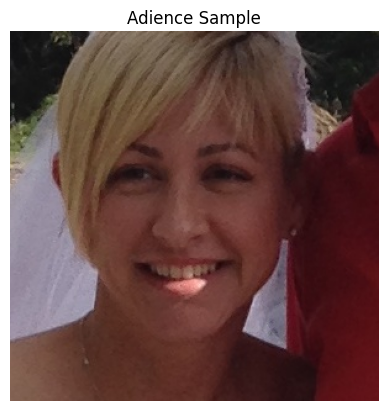

Age  : (25, 32)
Gender: f


In [18]:
# Get one image that actually exists
sample_path = df_adience[df_adience["file_exists"] == True]["filepath"].iloc[0]

img = mpimg.imread(sample_path)

plt.imshow(img)
plt.title("Adience Sample")
plt.axis("off")
plt.show()

print("Age  :", df_adience[df_adience["filepath"] == sample_path]["age"].values[0])
print("Gender:", df_adience[df_adience["filepath"] == sample_path]["gender"].values[0])

In [19]:
# Keep only rows where image actually exists on disk
df_adience_clean = df_adience[df_adience["file_exists"] == True].copy()

print("Adience usable images:", len(df_adience_clean))

Adience usable images: 3086


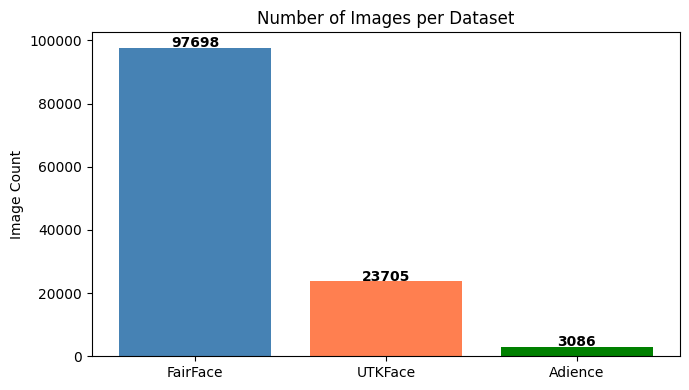

In [20]:
counts = {
    "FairFace": len(df_fairface),
    "UTKFace":  len(df_utk),
    "Adience":  len(df_adience_clean)
}

plt.figure(figsize=(7, 4))
plt.bar(counts.keys(), counts.values(), color=["steelblue", "coral", "green"])
plt.title("Number of Images per Dataset")
plt.ylabel("Image Count")
for i, (k, v) in enumerate(counts.items()):
    plt.text(i, v + 200, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

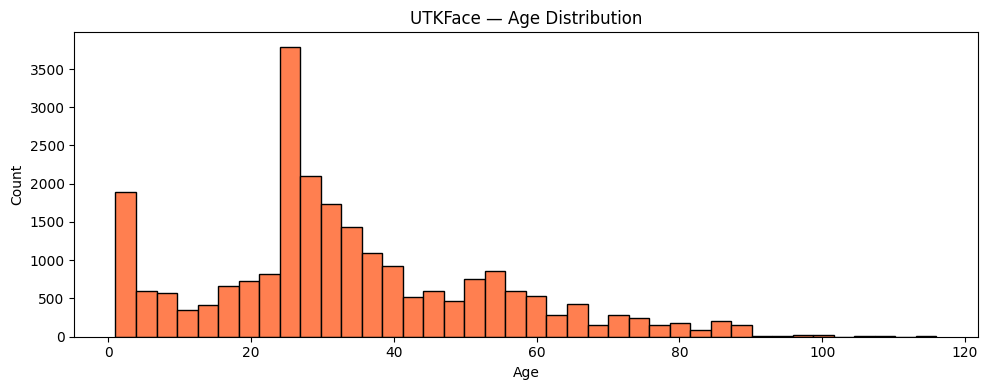

Min age: 1
Max age: 116
Mean age: 33.3


In [21]:
plt.figure(figsize=(10, 4))
plt.hist(df_utk["age"], bins=40, color="coral", edgecolor="black")
plt.title("UTKFace — Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Min age:", df_utk["age"].min())
print("Max age:", df_utk["age"].max())
print("Mean age:", round(df_utk["age"].mean(), 1))

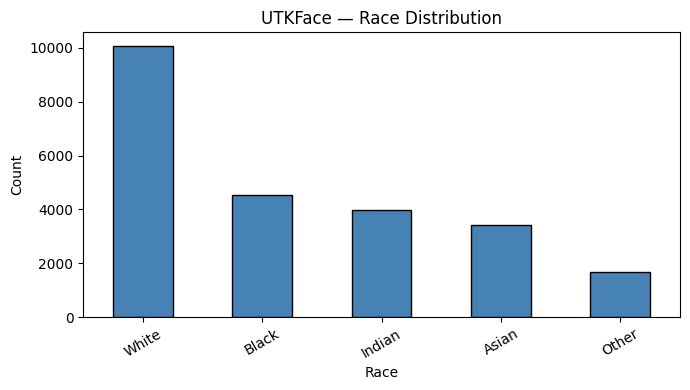

In [22]:
plt.figure(figsize=(7, 4))
df_utk["race"].value_counts().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("UTKFace — Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

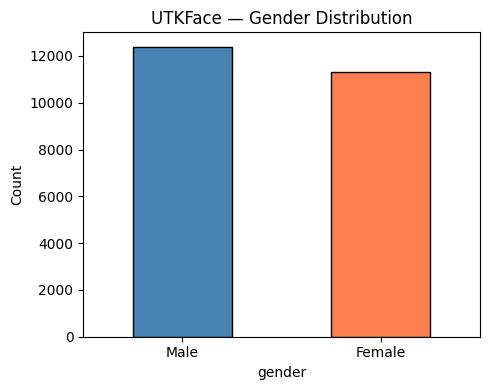

In [23]:
plt.figure(figsize=(5, 4))
df_utk["gender"].value_counts().plot(kind="bar", color=["steelblue", "coral"], edgecolor="black")
plt.title("UTKFace — Gender Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

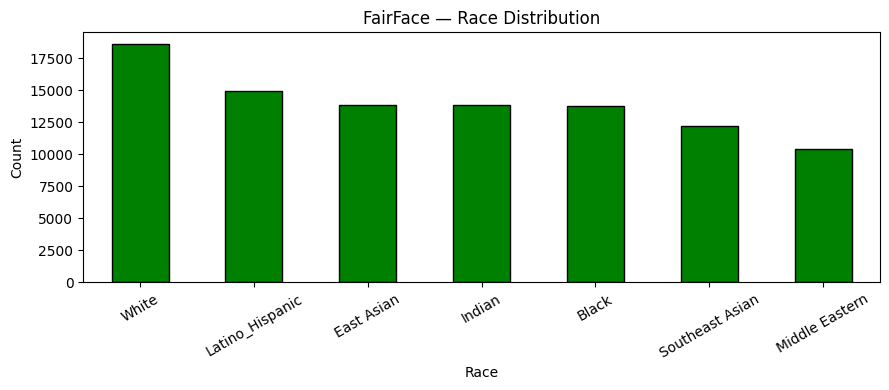

In [24]:
plt.figure(figsize=(9, 4))
df_fairface["race"].value_counts().plot(kind="bar", color="green", edgecolor="black")
plt.title("FairFace — Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

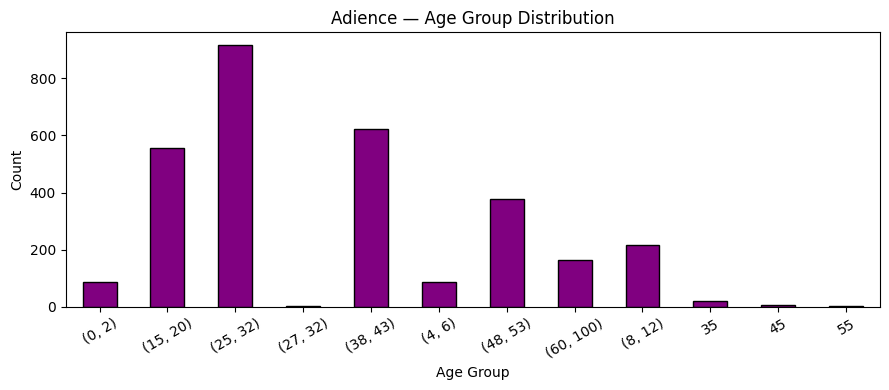

In [25]:
plt.figure(figsize=(9, 4))
df_adience_clean["age"].value_counts().sort_index().plot(kind="bar", color="purple", edgecolor="black")
plt.title("Adience — Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

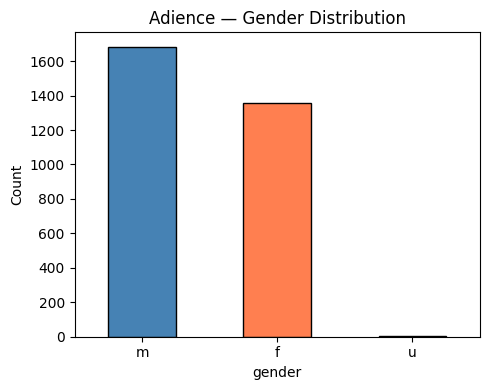

In [26]:
plt.figure(figsize=(5, 4))
df_adience_clean["gender"].value_counts().plot(kind="bar", color=["steelblue", "coral"], edgecolor="black")
plt.title("Adience — Gender Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

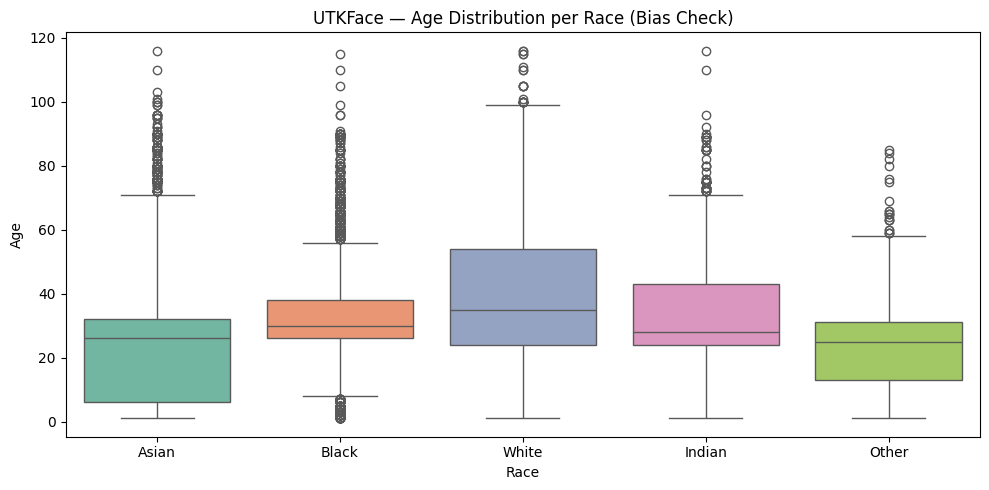

In [27]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_utk, x="race", y="age", palette="Set2")
plt.title("UTKFace — Age Distribution per Race (Bias Check)")
plt.xlabel("Race")
plt.ylabel("Age")
plt.tight_layout()
plt.show()